# Monitoring Amazonas Deforestation

# This notebook demonstrates an end-to-end geospatial workflow:
# - Authentication with UP42 API
# - Catalog search for Sentinel-2 imagery
# - Scene selection based on AOI, time range, and cloud coverage
# - Download of spectral bands (Red and NIR)
# - STAC metadata exploration
# - NDVI computation for vegetation monitoring
# - Temporal analysis and change detection

In [ ]:
# Import libraries.
# Standard geospatial and data processing libraries for remote sensing workflow.

import os
import glob
import logging
import json
import time
from datetime import datetime

from dotenv import load_dotenv
import requests
import rasterio
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Configure logging.
# Load environment variables from a .env file to securely manage credentials.

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)

load_dotenv()

True

In [ ]:
################
## User input ##
################

# Please note: this notebook must be placed in: "PROJECT FOLDER / notebook"

# Define spatial, temporal, and spectral scope of the analysis:

# ORDERING DATA:
# 1. AOI: must be placed in PROJECT FOLDER / DATA / INPUT
aoi_filename = "amazonas.geojson"

# 2. Year range defines the temporal extent of the analysis.
# This enables a multi-year NDVI time series for long-term vegetation monitoring.
year_rage = range(2015,2026)

# July is selected as the reference month for each year.
# This choice is based the following considerations:
# - Start of dry season in Amazonas: reduced cloud cover compared to wet season
# - Lower fire activity compared to later dry-season months
month = 7

# DOWNLOADING DATA:
# 1. July is selected as the reference month for each year (see above).
target_month = "07"

# 2. Sentinel-2 bands used for NDVI computation:
# NDVI = (NIR - RED) / (NIR + RED)
# Only the minimum required spectral bands are downloaded to reduce storage and processing cost.
bands = {
    "red": "b04.tiff",
    "nir": "b08.tiff"
}

In [ ]:
# Define input and output directories.
# Raw satellite data and derived NDVI outputs are stored separately.

# Input AOI
AOI_PATH = f"../data/input/{aoi_filename}"

# Folder to save raw satellite imagery (if folder doesn't exist, it will be created)
raw_data_dir = "../data/output/raw"
os.makedirs(raw_data_dir, exist_ok=True)

# Folder to save raw satellite imagery (if folder doesn't exist, it will be created)
ndvi_data_dir = "../data/output/ndvi"
os.makedirs(ndvi_data_dir, exist_ok=True)
 

In [ ]:
##############################
## BLOCK 1: TO CREATE ORDER ##
##############################

# Authenticate against UP42 OAuth2 API using credentials stored in environment variables.
# This returns an access token valid for 5 minutes, required for all subsequent API requests.
# Source: https://docs.up42.com/developers/authentication
username = os.getenv("UP42_USERNAME")
password = os.getenv("UP42_PASSWORD")

response = requests.post(
    "https://auth.up42.com/realms/public/protocol/openid-connect/token",
    data={
        "username": username,
        "password": password,
        "grant_type": "password",
        "client_id": "up42-api"
    }
)

if response.status_code == 200:
    token = response.json()["access_token"]
    logger.info("New token. Status code: %s", response.status_code)
else:
    logger.error("Token creation failed: %s", response.status_code)

if "token" not in locals():
    raise RuntimeError("Authentication failed - token not generated")

# Define request headers for authenticated API communication.
# Separate header configurations are used for GET and POST requests.

# Headers for GET requests
headers_get = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}

# Headers for POST requests
headers_post = {
    "Authorization": f"Bearer {token}",
    "accept": "application/json",
    "content-type": "application/json"
}

2026-04-15 23:08:11,140 [INFO] New token. Status code: 200


In [ ]:
# Retrieve all available UP42 collections using the v2 collections endpoint.
# Pagination is required because results are returned in multiple pages.
# Source: https://developer.up42.com/reference/listcollectionsv2

url = "https://api.up42.com/v2/collections"

# Screen first page for content and total number of pages.
response = requests.get(url,
                        headers=headers_get,
                        params={"page": 1})

data = response.json()
total_pages = data["totalPages"]
combined_collections = data["content"]

# Loop through pages and append further content.
for page in range(2, total_pages+1):
    response = requests.get(url, headers=headers_get, params={"page": page})
    data = response.json()
    combined_collections.extend(data["content"])

if response.status_code == 200:
    logger.info("Collection list successful. Status code: %s", response.status_code)
else:
    logger.error("Collection list failed: %s", response.status_code)

names = [c["name"] for c in combined_collections]

2026-04-15 22:32:48,628 [INFO] Collection list successful. Status code: 200


In [ ]:
# Extract the Sentinel-2 collection from the full list of available UP42 datasets.

sentinel_info = []

for c in combined_collections:
    if c["name"] == 'sentinel-2':
        sentinel_info = c

sentinel_collection_name = sentinel_info["name"]
sentinel_collection_id = sentinel_info["dataProducts"][0]["name"]
sentinel_product_id = sentinel_info["dataProducts"][0]["id"]

logger.info("Sentinel collection name: %s", sentinel_collection_name)

2026-04-15 22:32:54,675 [INFO] Sentinel collection name: sentinel-2


In [ ]:
# Query UP42 STAC search endpoint (EarthSearch on AWS) for Sentinel-2 scenes.
# Filtering:
# - Spatial filter: restricts results to AOI in Amazonas
# - Temporal filter: ensures same seasonal period across years (July)
# - Collection filter: ensures only Sentinel-2 imagery is retrieved
# - Cloud coverage filter (≤20%): reduces unusable scenes

# Load Area of Interest (AOI) geometry from GeoJSON file.
# This defines the spatial constraint for all satellite queries.
with open(AOI_PATH) as f:
    aoi = json.load(f)

# Construct yearly time ranges for the selected month (July).
# A fixed 28-day window is used to ensure API compatibility across all months
# and avoid edge-case failures due to varying month lengths.
timeranges = [f"{year}-{month:02d}-01T00:00:00Z/{year}-{month:02d}-28T23:59:59Z" for year in year_rage]

# Select scenes from Sentinel-2 collection matching user input (AOI, year range, month)
# To use comparable data for the index calculation, target month is a single value (see User Input code cell)
selected_scene_ids = []

url = "https://api.up42.com/catalog/hosts/earthsearch-aws/stac/search"

for timerange in timeranges:
    logger.info("CURRENT YEAR: %s", timerange)

    payload = {
        "datetime": timerange,
        "limit": 250,
        "intersects": aoi["features"][0]["geometry"],
        "collections": [sentinel_collection_name],
        "query": {
            "cloudCoverage": {"lte": 20}
        }
    }

    response = requests.post(url, json=payload, headers=headers_post)

    if response.status_code != 200:
        logger.error("Request failed for %s : %s", timerange, response.text)
        continue

    data = response.json()

    if not data["features"]:
        logger.error("No scenes found")
        logger.info("-" * 50)
        continue

    # From the filtered candidates in each year, the scene with the lowest cloud coverage is selected to maximize visibility.
    best_scene = None
    best_cloud = float("inf")

    for f in data["features"]:
        props = f["properties"]
        cloud = props.get("eo:cloud_cover", props.get("cloudCoverage", 100))

        if cloud < best_cloud:
                    best_cloud = cloud
                    best_scene = props["sceneId"]

    logger.info("A scene with a cloud cover of: %s was selected", best_cloud)
    logger.info("-" * 50)

    if best_scene:
        selected_scene_ids.append(best_scene)

logger.info("Total filtered scenes: %s", len(selected_scene_ids))

2026-04-15 22:33:00,085 [INFO] CURRENT YEAR: 2015-07-01T00:00:00Z/2015-07-28T23:59:59Z


2026-04-15 22:33:00,948 [ERROR] No scenes found
2026-04-15 22:33:00,951 [INFO] --------------------------------------------------
2026-04-15 22:33:00,953 [INFO] CURRENT YEAR: 2016-07-01T00:00:00Z/2016-07-28T23:59:59Z
2026-04-15 22:33:01,384 [ERROR] No scenes found
2026-04-15 22:33:01,386 [INFO] --------------------------------------------------
2026-04-15 22:33:01,387 [INFO] CURRENT YEAR: 2017-07-01T00:00:00Z/2017-07-28T23:59:59Z
2026-04-15 22:33:01,794 [ERROR] No scenes found
2026-04-15 22:33:01,797 [INFO] --------------------------------------------------
2026-04-15 22:33:01,799 [INFO] CURRENT YEAR: 2018-07-01T00:00:00Z/2018-07-28T23:59:59Z
2026-04-15 22:33:02,557 [INFO] A scene with a cloud cover of: 0.00139 was selected
2026-04-15 22:33:02,559 [INFO] --------------------------------------------------
2026-04-15 22:33:02,560 [INFO] CURRENT YEAR: 2019-07-01T00:00:00Z/2019-07-28T23:59:59Z
2026-04-15 22:33:03,292 [INFO] A scene with a cloud cover of: 0.002279 was selected
2026-04-15 22

In [ ]:
# Create an order for each selected Sentinel-2 scene
# URL: https://developer.up42.com/reference/createv2orderunderworkspace?utm_source=documentation

# Each order requests is:
# - A specific Sentinel-2 scene
# - Spatial clipping to the AOI
# - A predefined band

# The data is generated server-side before being made available for download.

# Please note: EULA was accepted on the platform
# Potential improvement: accept EULA based on: https://developer.up42.com/reference/accepteuladocumentv2?utm_source=documentation

# Workspace ID:
workspace_id = os.getenv("UP42_WORKSPACE_ID")

if not workspace_id:
    raise RuntimeError("Missing UP42_WORKSPACE_ID")

# Data product ID:
sentinel_product_id

url = f"https://api.up42.com/v2/orders?workspaceId={workspace_id}"

order_ids = []

for scene_id in selected_scene_ids:
    payload = {
        "displayName": f"Sentinel-2 Amazonas {scene_id}",
        "dataProduct": sentinel_product_id,
        "featureCollection": {
            "type": "FeatureCollection",
            "features": [
                {
                    "type": "Feature",
                    "geometry": aoi["features"][0]["geometry"]
                }
            ]
        },
        "params": {
            "id": scene_id
        }
    }

    response = requests.post(url, json=payload, headers=headers_post)

    logger.info("Scene ID: %s -> Status code: %s", scene_id, response.status_code)

    if response.status_code not in [200, 202]:
        raise RuntimeError(
            f"Order creation failed for {scene_id}: {response.status_code} {response.text}"
        )

    data = response.json()

    order_id = data.get("results", [{}])[0].get("id")

    if not order_id:
        raise RuntimeError(f"Missing order id for {scene_id}: {data}")

    order_ids.append(order_id)

if not order_ids:
    raise RuntimeError("No orders created - stopping execution")

2026-04-15 22:33:20,071 [INFO] Scene ID: S2B_T21LXF_20180726T140049_L2A -> Status code: 202
2026-04-15 22:33:21,308 [INFO] Scene ID: S2A_T21LXF_20190716T140057_L2A -> Status code: 202
2026-04-15 22:33:22,314 [INFO] Scene ID: S2B_T21LXF_20200715T140053_L2A -> Status code: 202
2026-04-15 22:33:23,035 [INFO] Scene ID: S2B_T21LXF_20210720T140054_L2A -> Status code: 202
2026-04-15 22:33:24,376 [INFO] Scene ID: S2B_T21LXF_20230710T135712_L2A -> Status code: 202
2026-04-15 22:33:25,681 [INFO] Scene ID: S2A_T21LXF_20240709T140010_L2A -> Status code: 202
2026-04-15 22:33:26,968 [INFO] Scene ID: S2A_T21LXF_20250706T140113_L2A -> Status code: 202


In [ ]:
# Track processing status of the latest orders.
# This step validates that all scenes reach the "FULFILLED" state before data download begins.

url_base = "https://api.up42.com/v2/orders"

for order_id in order_ids:
    url = f"{url_base}/{order_id}"
    response = requests.get(url, headers=headers_get)

    if response.status_code != 200:
        logger.error("Failed to fetch status for order. Status: %s", response.status_code)
        continue

    logger.info("STATUS CODE: %s", response.status_code)

    data = response.json()

    status = (
        data.get("result", {}).get("status")
        or data.get("status")
    )

    logger.info("STATUS: %s", status)

2026-04-15 22:56:07,339 [INFO] STATUS CODE: 200
2026-04-15 22:56:07,341 [INFO] STATUS: FULFILLED
2026-04-15 22:56:07,554 [INFO] STATUS CODE: 200
2026-04-15 22:56:07,556 [INFO] STATUS: FULFILLED
2026-04-15 22:56:07,761 [INFO] STATUS CODE: 200
2026-04-15 22:56:07,762 [INFO] STATUS: FULFILLED
2026-04-15 22:56:07,986 [INFO] STATUS CODE: 200
2026-04-15 22:56:07,987 [INFO] STATUS: FULFILLED
2026-04-15 22:56:08,203 [INFO] STATUS CODE: 200
2026-04-15 22:56:08,206 [INFO] STATUS: FULFILLED
2026-04-15 22:56:08,430 [INFO] STATUS CODE: 200
2026-04-15 22:56:08,432 [INFO] STATUS: FULFILLED
2026-04-15 22:56:08,657 [INFO] STATUS CODE: 200
2026-04-15 22:56:08,658 [INFO] STATUS: FULFILLED


In [ ]:
#######################################
## BLOCK 2: TO DOWNLOAD ORDERED DATA ##
#######################################

# Inspect STAC asset collections available for download.
# Source: https://developer.up42.com/reference/getsascollections?utm_source=documentation

# This step is exploratory and to validate that required Sentinel-2 assets (bands and metadata) are available.

url = "https://api.up42.com/v2/assets/stac/collections"
params = {
    "limit": 10
}

response = requests.get(
    url,
    headers=headers_get,
    params=params
)

# Print status code
logger.info("Status code: %s", response.status_code)

data = response.json()

collections = data.get("collections", [])

if not collections:
    logger.warning("Empty STAC collections response")

logger.info("Number of downloaded collections: %s", len(collections))

for c in collections:
    logger.info("Description: %s", c.get("description"))
    logger.info("Extent: %s", c.get("extent"))
    logger.info("-"* 50)

2026-04-15 22:56:19,045 [INFO] Status code: 200
2026-04-15 22:56:19,047 [INFO] Number of downloaded collections: 7
2026-04-15 22:56:19,049 [INFO] Description: Sentinel-2 is an Earth observation mission from the Copernicus Programme by the European Space Agency providing Open Data for anybody to use. It's imaging satellites carry wide swath medium-resolution multispectral sensors with 13 spectral bands and they systematically acquire optical imagery at high spatial resolution (10 m to 60 m) over land and coastal waters. The satellites were manufactured by a consortium led by Airbus Defence and Space.
2026-04-15 22:56:19,050 [INFO] Extent: {'spatial': {'bbox': [[-56.07909832604045, -13.655153200298894, -55.06048783693054, -12.657006390818566]]}, 'temporal': {'interval': [['2020-07-15T14:06:12Z', '2020-07-15T14:06:12Z']]}}
2026-04-15 22:56:19,052 [INFO] --------------------------------------------------
2026-04-15 22:56:19,053 [INFO] Description: Sentinel-2 is an Earth observation mission

In [ ]:
# Explore STAC API metadata

# This section further explores STAC metadata hierarchy:
# - Collection level: dataset metadata
# - Feature level: individual scenes
# - Asset level: spectral bands

# This inspection confirms availability of required bands for NDVI computation.

# Select a collection.
demo_collection = collections[0]
demo_collection_id = demo_collection["id"]

# Explore the selected collection.
logger.info("EXPLORE A COLLECTION")
logger.info(f"COLLECTION keys: {list(demo_collection.keys())}")
logger.info(f"Type: {demo_collection.get('type')}")
logger.info(f"Description: {demo_collection.get('description')}")
logger.info(f"Keywords: {demo_collection.get('keywords')}")
logger.info(f"="*50)

# Explore features (scenes) within the selected collection.
url = f"https://api.up42.com/v2/assets/stac/collections/{demo_collection_id}/items"
stac_response = requests.get(url, headers=headers_get)
data = stac_response.json()
logger.info("FEATURES (SCENES)")
logger.info(f"FEATURE keys: {list(data.keys())}")
logger.info(f"Type: {data.get('type')}")

scenes = data.get("features", [])

if not scenes:
    logger.warning("No STAC features found for collection %s", demo_collection_id)

logger.info(f"Number of features (scenes): {len(scenes)}")
logger.info(f"="*50)

# Explore a feature (scene).
logger.info("EXPLORE A FEATURE")

scene = scenes[0]
item_url = f"https://api.up42.com/v2/assets/stac/collections/{demo_collection_id}/items/{scene['id']}"
logger.info("STAC item URL: %s", item_url)

logger.info(f"FEATURE keys: {list(scene.keys())}")
logger.info(f"Datetime: {scene['properties'].get('datetime')}")
logger.info(f"Platform: {scene['properties'].get('platform')}")
logger.info(f"Cloud cover: {scene['properties'].get('eo:cloud_cover')}")
logger.info(f"Geometry type: {scene['geometry']['type']}")
logger.info(f"BBox: {scene['bbox']}")
logger.info(f"="*50)

# Explore assets (bands).
asset = scene["assets"]
logger.info("ASSETS (BANDS)")
logger.info(f"List of ASSETS: {list(asset.keys())}")
logger.info(f"="*50)

# Select and explore an asset.
logger.info("EXPLORE AN ASSET")
b01 = asset.get("b01.tiff")
logger.info("b01.tiff asset details:")
logger.info(f"  Href: {b01.get('href')}")
logger.info(f"  Type: {b01.get('type')}")
logger.info(f"  Roles: {b01.get('roles')}")

2026-04-15 22:59:21,300 [INFO] EXPLORE A COLLECTION
2026-04-15 22:59:21,303 [INFO] COLLECTION keys: ['assets', 'links', 'stac_extensions', 'title', 'description', 'stac_version', 'keywords', 'license', 'providers', 'extent', 'type', 'id', 'created_at', 'updated_at', 'summaries', 'up42-order:id', 'up42-user:title', 'up42-system:source', 'up42-system:asset_id', 'up42-product:modality', 'up42-system:account_id', 'up42-product:product_id', 'up42-system:workspace_id', 'up42-product:collection_name', 'up42-system:metadata_version']
2026-04-15 22:59:21,305 [INFO] Type: Collection
2026-04-15 22:59:21,309 [INFO] Description: Sentinel-2 is an Earth observation mission from the Copernicus Programme by the European Space Agency providing Open Data for anybody to use. It's imaging satellites carry wide swath medium-resolution multispectral sensors with 13 spectral bands and they systematically acquire optical imagery at high spatial resolution (10 m to 60 m) over land and coastal waters. The satell

2026-04-15 22:59:21,706 [INFO] FEATURES (SCENES)
2026-04-15 22:59:21,708 [INFO] FEATURE keys: ['links', 'type', 'features', 'context']
2026-04-15 22:59:21,711 [INFO] Type: FeatureCollection
2026-04-15 22:59:21,713 [INFO] Number of features (scenes): 1
2026-04-15 22:59:21,717 [INFO] ==================================================
2026-04-15 22:59:21,719 [INFO] EXPLORE A FEATURE
2026-04-15 22:59:21,721 [INFO] STAC item URL: https://api.up42.com/v2/assets/stac/collections/dbf9c446-dc5c-4b46-832a-220daa7f1644/items/24eacff0-717b-4108-a1ec-e5cddbc9fa31
2026-04-15 22:59:21,724 [INFO] FEATURE keys: ['geometry', 'bbox', 'assets', 'links', 'stac_extensions', 'properties', 'type', 'stac_version', 'id', 'collection']
2026-04-15 22:59:21,726 [INFO] Datetime: 2020-07-15T14:06:12Z
2026-04-15 22:59:21,727 [INFO] Platform: sentinel-2b
2026-04-15 22:59:21,729 [INFO] Cloud cover: 0.001466
2026-04-15 22:59:21,732 [INFO] Geometry type: Polygon
2026-04-15 22:59:21,734 [INFO] BBox: [-56.0790983260405, -1

In [ ]:
# Filter available collections based on target month (July).

# This restricts the analysis to scenes acquired in the same seasonal period.
# Only collections matching the target month are kept for downstream processing.

collection_id_list = []

for collection in collections:

    interval = collection.get("extent", {}).get("temporal", {}).get("interval", [])
    start_date = interval[0][0]
    month = start_date[5:7]

    if month == target_month:
        collection_id_list.append(collection["id"])

logger.info("Sentinel-2 collections selected for the user defined month of year: %s", target_month)

2026-04-15 23:05:30,569 [INFO] Sentinel-2 collections selected for the user defined month of year: 07


In [ ]:
# Download Sentinel-2 bands for NDVI computation:
# - Red band (B04)
# - Near Infrared band (B08)

# Data is accessed via download URLs generated from STAC asset endpoints.
# Source: https://developer.up42.com/reference/generatedownloadurlexternal?utm_source=documentation

# Please note: cloud cover mask could be added to the downloaded band to further improve processing output quality.

for collection_id in collection_id_list:

    url = f"https://api.up42.com/v2/assets/stac/collections/{collection_id}/items"

    stac_response = requests.get(url, headers=headers_get)

    data = stac_response.json()
    scenes = data["features"]

    # Each timestamp has one scene with all bands (assets) and metadata.
    for scene in scenes:
        assets = scene["assets"]
        timestamp = scene["properties"]["datetime"].split("T")[0]

        # Loop through each GeoTiff from the bands dictionary above.
        for band_name, band_tiff_name in bands.items():

                if band_tiff_name not in assets:
                    raise ValueError(f"Missing band {band_tiff_name}")

                # Create download URL.
                href = assets[band_tiff_name]["href"]
                download_url_endpoint = f"{href}/download-url"

                url_response = requests.post(download_url_endpoint, headers=headers_post)
                download_info = url_response.json()
        
                # Save file locally.
                file_url = download_info["url"]
                file_response = requests.get(file_url)

                file_path = f"{raw_data_dir}/{collection_id}_{timestamp}_{band_name}.tif"
                with open(file_path, "wb") as f:
                    f.write(file_response.content)

                # A short delay is applied among downloads.
                time.sleep(0.5)

logger.info("STAC assets successfully landed locally.")

2026-04-15 23:11:04,409 [INFO] STAC assets successfully landed locally.


In [ ]:
##############################
## BLOCK 3: TO PROCESS NDVI ##
##############################

# Local pair-wise grouping of Red and NIR raster files into scene pairs, based on filename structure.
# This step reconstructs temporal scenes locally by matching:
# - Collection ID
# - Timestamp

red_files = glob.glob(os.path.join(raw_data_dir, "*_red.tif"))

scenes = []

for red_path in red_files:

    filename = os.path.basename(red_path)
    
    # Extract ID + timestamp
    # some-id_2025-07-06_red.tif >>> some-id
    parts = filename.split("_")
    collection_id = parts[0]
    # some-id_2025-07-06_red.tif >>> 2025-07-06
    timestamp = parts[1]
    
    nir_path = f"{raw_data_dir}/{collection_id}_{timestamp}_nir.tif"

    if not os.path.exists(red_path) or not os.path.exists(nir_path):
        logger.warning("Missing band files for %s at %s", collection_id, timestamp)
        continue

    if os.path.exists(nir_path):
        scenes.append({
            "id": collection_id,
            "timestamp": timestamp,
            "red": red_path,
            "nir": nir_path
        })
    else:
        logger.error("Missing NIR for: %s", filename)

logger.info("Local files detected successfully. Ready for NDVI calculations.")

2026-04-15 23:12:55,088 [INFO] Local files detected successfully. Ready for NDVI calculations.


In [ ]:
# Compute NDVI for each scene.

# NDVI is a proxy for vegetation health: higher values indicate dense vegetation.

# Basic validity checks to ensure:
# - Consistent raster shapes
# - Consistent georeferencing transforms

# Invalid or zero pixels are masked to avoid NDVI distortions.

scene_stats_inputs = []

for scene in scenes:

    red_path = scene["red"]
    nir_path = scene["nir"]
    timestamp = scene["timestamp"]
    collection_id = scene["id"]

    output_path = f"{ndvi_data_dir}/{collection_id}_{timestamp}_ndvi.tif"
    
    if not os.path.exists(output_path):

        with rasterio.open(red_path) as red_dataset, rasterio.open(nir_path) as nir_dataset:

            assert red_dataset.shape == nir_dataset.shape
            if red_dataset.shape != nir_dataset.shape:
                raise ValueError(f"Shape mismatch: {red_dataset.shape} vs {nir_dataset.shape}")
            
            assert red_dataset.transform == nir_dataset.transform

            profile = red_dataset.profile.copy()
            profile.update(dtype=rasterio.float32,count=1,compress='lzw')

            with rasterio.open(output_path, "w", **profile) as dst:

                # Processing is done in raster blocks to optimize memory usage.
                for ji, window in red_dataset.block_windows(1):

                    red_band = red_dataset.read(1, window=window).astype(np.float32)
                    nir_band = nir_dataset.read(1, window=window).astype(np.float32)

                    mask = (red_band == 0) | (nir_band == 0)

                    ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-6)
                    ndvi[mask] = np.nan

                    dst.write(ndvi, 1, window=window)

        logger.info("Finished processing NDVI for: %s - %s", collection_id, timestamp)

    else:
        logger.info("NDVI already calculated for: %s - %s", collection_id, timestamp)

    # Append all relevant data for NDVI mean calculations in the steps downstream.
    scene_stats_inputs.append({
        "collection_id": collection_id,
        "timestamp": timestamp,
        "ndvi_path": output_path
    })

2026-04-15 23:14:21,381 [INFO] Finished processing NDVI for: 0c5f73d1-58af-4c04-a0c6-abb6f29e38ba - 2025-07-06
2026-04-15 23:14:48,088 [INFO] Finished processing NDVI for: 3c987785-8a99-480c-9ab1-ab3089a07cc2 - 2023-07-10
2026-04-15 23:15:14,565 [INFO] Finished processing NDVI for: 57448be3-a962-43a0-bbd2-517d50e190e6 - 2018-07-26
2026-04-15 23:15:39,940 [INFO] Finished processing NDVI for: 57cbc79c-931d-4c26-bff2-57d8361ffbab - 2021-07-20
2026-04-15 23:16:06,948 [INFO] Finished processing NDVI for: 63eea296-c35d-43c6-b33d-fd9adfcb0178 - 2024-07-09
2026-04-15 23:16:30,872 [INFO] Finished processing NDVI for: aa4cd35a-f477-4e5c-8109-793b0b35a63d - 2019-07-16
2026-04-15 23:16:58,245 [INFO] Finished processing NDVI for: dbf9c446-dc5c-4b46-832a-220daa7f1644 - 2020-07-15


In [ ]:
# Compute mean NDVI per scene.
# This step aggregates pixel-level NDVI values into a single metric per NDVI raster.

scene_stats = []

for scene in scene_stats_inputs:

    ndvi_path = scene["ndvi_path"]
    
    try:
        timestamp = datetime.fromisoformat(scene["timestamp"])
    except Exception:
        logger.warning("Invalid timestamp format: %s", scene["timestamp"])
        continue

    with rasterio.open(ndvi_path) as src:
        ndvi = src.read(1).astype(np.float32)

        # Replace nodata (-9999) by NaN.
        if src.nodata is not None:
            ndvi = np.where(ndvi == src.nodata, np.nan, ndvi)

        mean_ndvi = np.nanmean(ndvi)

    scene_stats.append({
        "collection_id": scene["collection_id"],
        "timestamp": timestamp,
        "mean_ndvi": mean_ndvi,
        "ndvi_path" : ndvi_path
    })

for c in scene_stats:
    logger.info("Collection ID: %s", c.get("collection_id"))
    logger.info("Timestamp: %s", c.get("timestamp"))
    logger.info("Mean NDVI: %s", c.get("mean_ndvi"))
    logger.info(f"="*50)

2026-04-15 23:20:29,516 [INFO] Collection ID: 0c5f73d1-58af-4c04-a0c6-abb6f29e38ba
2026-04-15 23:20:29,520 [INFO] Timestamp: 2025-07-06 00:00:00
2026-04-15 23:20:29,521 [INFO] Mean NDVI: 0.29166648
2026-04-15 23:20:29,523 [INFO] ==================================================
2026-04-15 23:20:29,524 [INFO] Collection ID: 3c987785-8a99-480c-9ab1-ab3089a07cc2
2026-04-15 23:20:29,525 [INFO] Timestamp: 2023-07-10 00:00:00
2026-04-15 23:20:29,527 [INFO] Mean NDVI: 0.2759366
2026-04-15 23:20:29,528 [INFO] ==================================================
2026-04-15 23:20:29,529 [INFO] Collection ID: 57448be3-a962-43a0-bbd2-517d50e190e6
2026-04-15 23:20:29,531 [INFO] Timestamp: 2018-07-26 00:00:00
2026-04-15 23:20:29,536 [INFO] Mean NDVI: 0.27196854
2026-04-15 23:20:29,540 [INFO] ==================================================
2026-04-15 23:20:29,545 [INFO] Collection ID: 57cbc79c-931d-4c26-bff2-57d8361ffbab
2026-04-15 23:20:29,557 [INFO] Timestamp: 2021-07-20 00:00:00
2026-04-15 23:20

2026-04-15 23:20:48,431 [INFO] FIRST DATE: 2018-07-26 00:00:00
2026-04-15 23:20:48,435 [INFO] LAST DATE: 2025-07-06 00:00:00


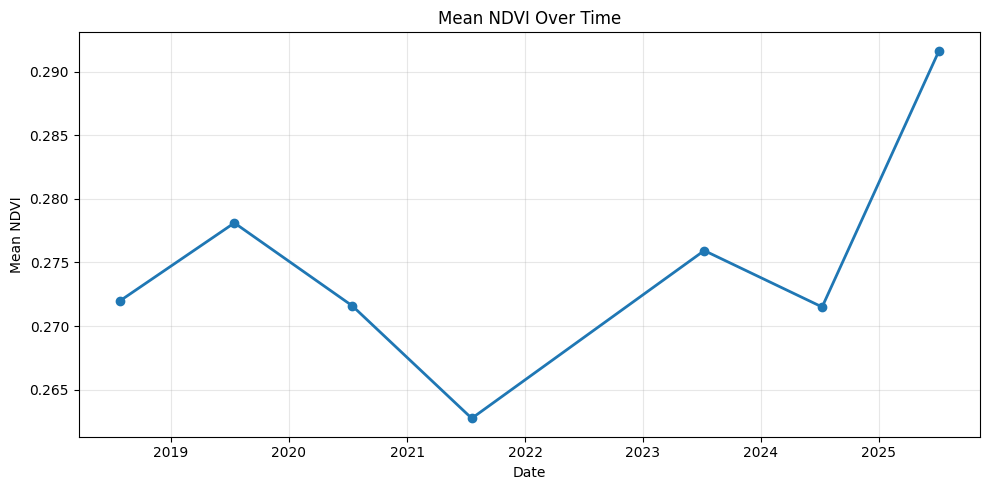

In [ ]:
# Plot mean NDVI over time.

# The resulting graph visualizes vegetation dynamics across multiple years (comparing July mean NDVI).

# Sort NDVI results based on time to ensure correct ordering.
timestamp = datetime.fromisoformat(parts[1])
scene_stats = sorted(scene_stats, key=lambda x: x["timestamp"])

logger.info("FIRST DATE: %s", scene_stats[0]["timestamp"])
logger.info("LAST DATE: %s", scene_stats[-1]["timestamp"])

dates = [s["timestamp"] for s in scene_stats]
means = [s["mean_ndvi"] for s in scene_stats]

# Plot graph
plt.figure(figsize=(10, 5))

plt.plot(dates, means, marker="o", linewidth=2)

plt.title("Mean NDVI Over Time")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


2026-04-15 23:23:39,527 [INFO] FIRST DATE: 2018-07-26 00:00:00
2026-04-15 23:23:39,536 [INFO] LAST DATE: 2025-07-06 00:00:00


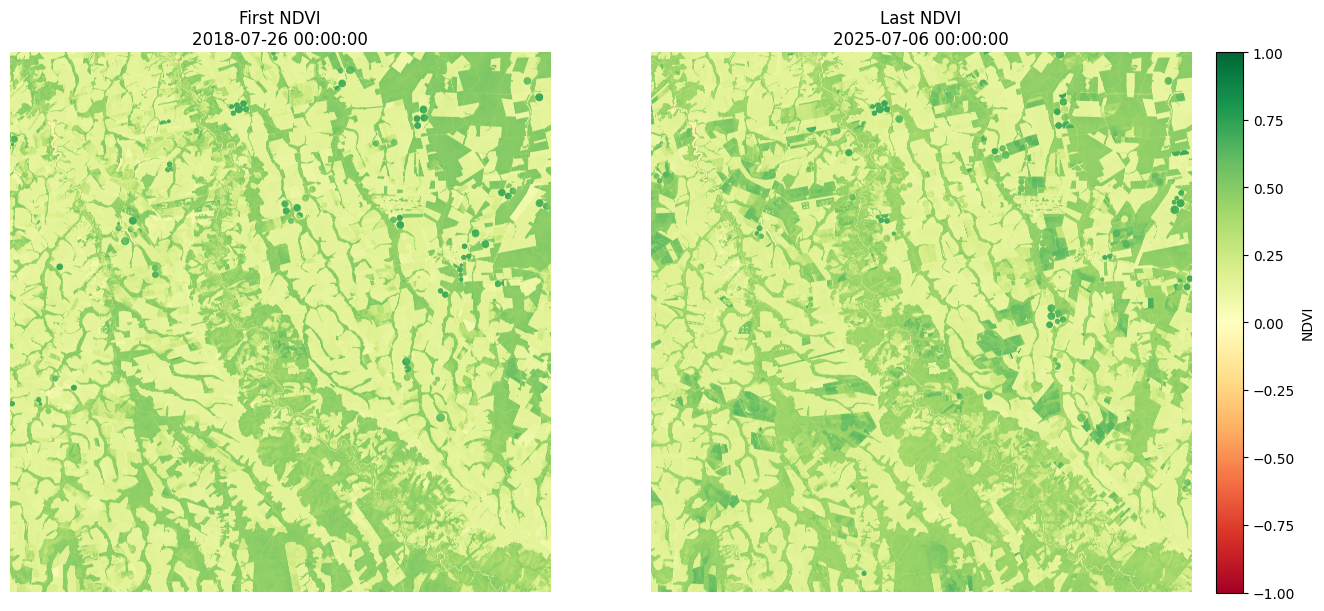

In [ ]:
# Visual comparison of static NDVI maps (between earliest and latest scenes).

# Both NDVI rasters are plotted using the same color scale (-1 to 1) to ensure comparability.

# Sort NSVI scenes by time
scene_stats = sorted(scene_stats, key=lambda x: x["timestamp"])

logger.info("FIRST DATE: %s", scene_stats[0]["timestamp"])
logger.info("LAST DATE: %s", scene_stats[-1]["timestamp"])

first = scene_stats[0]
last = scene_stats[-1]

with rasterio.open(first["ndvi_path"]) as src:
    ndvi_first = src.read(1).astype(np.float32)
    if src.nodata is not None:
        ndvi_first = np.where(ndvi_first == src.nodata, np.nan, ndvi_first)

with rasterio.open(last["ndvi_path"]) as src:
    ndvi_last = src.read(1).astype(np.float32)
    if src.nodata is not None:
        ndvi_last = np.where(ndvi_last == src.nodata, np.nan, ndvi_last)

# Plot maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

vmin, vmax = -1, 1

im1 = axes[0].imshow(ndvi_first, cmap="RdYlGn", vmin=vmin, vmax=vmax)
axes[0].set_title(f"First NDVI\n{first['timestamp']}")
axes[0].axis("off")

im2 = axes[1].imshow(ndvi_last, cmap="RdYlGn", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Last NDVI\n{last['timestamp']}")
axes[1].axis("off")

fig.colorbar(im1, ax=axes, fraction=0.03, pad=0.02, label="NDVI")

plt.show()


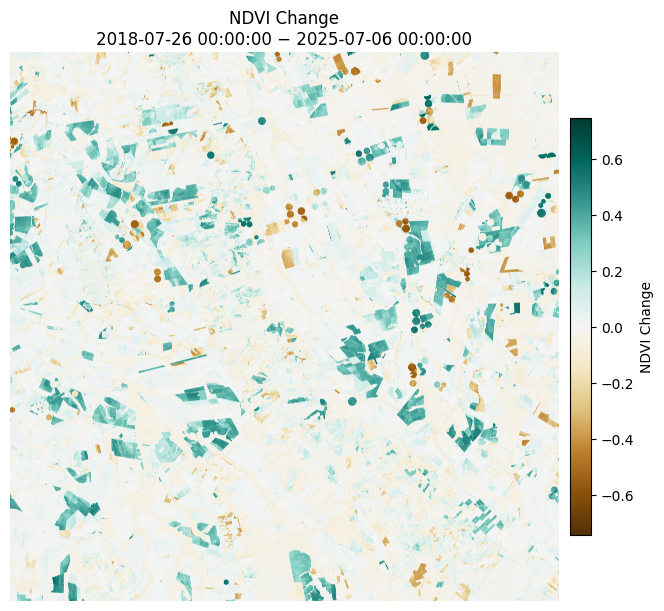

In [ ]:
# Prepare NDVI difference map between first and last year

# Compute NDVI difference between first and last observation years and visualize long-term vegetation change.
# Positive values indicate vegetation gain. Negative values indicate vegetation loss.

# Ensure same shape.
if ndvi_first.shape != ndvi_last.shape:
    raise ValueError(f"Shape mismatch: {ndvi_first.shape} vs {ndvi_last.shape}")

ndvi_diff = ndvi_last - ndvi_first
ndvi_diff = np.ma.masked_invalid(ndvi_diff)

# Plot map
fig, ax = plt.subplots(1, 1, figsize=(7, 6), constrained_layout=True)

cmap = plt.cm.BrBG

vmax = np.nanmax(np.abs(ndvi_diff))
vmin = -vmax

im = ax.imshow(ndvi_diff, cmap=cmap, vmin=vmin, vmax=vmax)

ax.set_title(
    f"NDVI Change\n"
    f"{first['timestamp']} − {last['timestamp']}"
)
ax.axis("off")

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("NDVI Change")

plt.show()

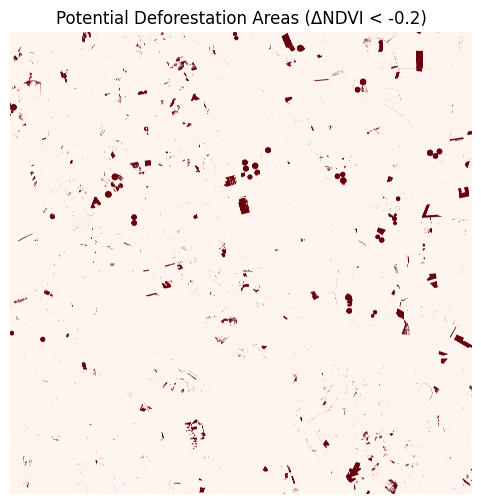

In [ ]:
# Identify deforestation areas based on significant NDVI decrease.
# Pixels with NDVI change below -0.2 are flagged here as significant vegetation loss.

deforestation_mask = ndvi_diff < -0.2

plt.figure(figsize=(7,6))
plt.imshow(deforestation_mask, cmap="Reds")
plt.title("Potential Deforestation Areas (ΔNDVI < -0.2)")
plt.axis("off")
plt.show()

# This workflow demonstrates how Sentinel-2 imagery can be used to monitor deforestation over time in the Amazonas region using NDVI.

# The NDVI difference map and the potential deforestation area map highlight areas of potential vegetation loss.

# Major limitations:
# - EULAs were reviewed and accepted on the UP42 console.
# - No cloud masking was applied, only cloud filtering.
# - The pipeline assumes consistent spatial alignment across scenes.